<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

galton_df = pd.read_csv('/content/galton.csv')
galton_df.head()

,family,father,mother,gender,height,kids
0,1,78.5,67.0,M,73.199997,4
1,1,78.5,67.0,F,69.199997,4
2,1,78.5,67.0,F,69.000000,4
3,1,78.5,67.0,F,69.000000,4
4,2,75.5,66.5,M,73.500000,4


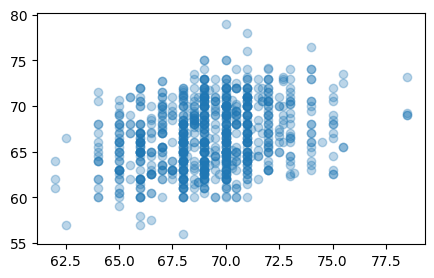

In [ ]:
# 아빠키와 자녀키 사이의 관계

import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))
plt.scatter(galton_df['father'], galton_df['height'], alpha=0.3)
plt.show()



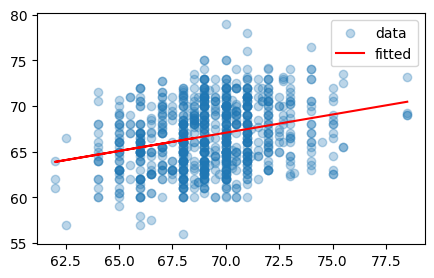

In [ ]:
# father 와 height의 회귀선을 추가
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

slope, intercept = stats.linregress(galton_df['father'], galton_df['height'])[:2]


plt.figure(figsize=(5,3))

plt.scatter(galton_df['father'], galton_df['height'],
            alpha=0.3, label='data')

plt.plot(galton_df['father'], slope*galton_df['father']+intercept,
         color='red', label = 'fitted')

plt.legend()
plt.show()





- regression line은 조건부 기대값을 선형으로 표시한 것이다.

$$
E[Y|X] =  a + b X
$$


ba### Simple (linear) regression model 단순(선형)회귀모형

- 회귀모형
$$
Y_i = \beta_0 + \beta_1 X_i + e_i
$$

- 몇 가지 가정을 한 후(나중에 자세히 기술)

- 오차의 제곱의 합을 정의
$$
\sum_{i=1}^n e_i^2
$$

- OLS 추정법(ordinary least square esimtation)
  - 오차의 제곱의 합을 가장 작게 만들어주는 $\beta_0, \beta_1$

$$
\hat{\beta}_1 = \frac{ \sum_{i=1}^n (X_i - \bar{X} ) (Y_i - \bar{Y} ) }{ \sum_{i=1}^n (X_i - \bar{X} )^2  }
$$




In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(formula='height ~ father', data=galton_df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     73.51
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           4.35e-17
Time:                        06:57:24   Log-Likelihood:                -2384.3
No. Observations:                 898   AIC:                             4773.
Df Residuals:                     896   BIC:                             4782.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.1104      3.227     12.120      0.0

### 간단한 시뮬레이션

- $y_i = 1 + x_i + e_i$

- $e_i \sim N(0,2^2)$

- $x_i \sim N(1,3^2)$

In [ ]:
# data generation
import numpy as np
import pandas as pd

np.random.seed(123)

n = 1000

x = np.random.normal(loc=1, scale=3, size=n)
e = np.random.normal(loc=0, scale=2, size=n)

y = 1 + x + e

df = pd.DataFrame({'x':x, 'y':y})
# df.head()

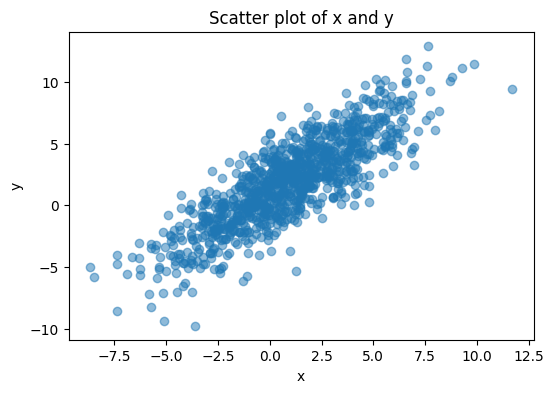

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['x'], df['y'], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of x and y')
# plt.grid(True)
plt.show()

In [ ]:
# OLS로 DGP(data generating process)를 복원할 수 있냐?
import statsmodels.formula.api as smf

model = smf.ols(formula='y ~ x', data = df)
result = model.fit()

print(result.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     2356.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          6.20e-265
Time:                        08:10:23   Log-Likelihood:                -2068.7
No. Observations:                1000   AIC:                             4141.
Df Residuals:                     998   BIC:                             4151.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0344      0.063     16.372      0.0

In [ ]:
# auto.csv

import pandas as pd

df = pd.read_csv('/content/auto.csv')
# auto_df.head()


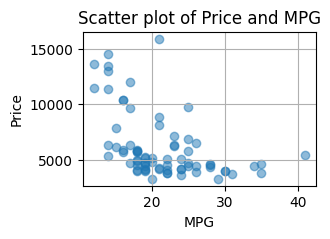

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,2))
plt.scatter(df['mpg'], df['price'], alpha=0.5)
plt.xlabel('MPG')
plt.ylabel('Price')
plt.title('Scatter plot of Price and MPG')
plt.grid(True)
plt.show()

- 종속변수를 price로 하고, 설명변수를 mpg 로 하는 회귀모형을 쓰고, 계수를 추정하시오.

$$
price_i = \beta_0 + \beta_1 \times mpg_i + e_i
$$



In [ ]:
import statsmodels.formula.api as smf

print(smf.ols(formula='price ~ mpg', data=df).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     20.26
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.55e-05
Time:                        08:32:42   Log-Likelihood:                -686.54
No. Observations:                  74   AIC:                             1377.
Df Residuals:                      72   BIC:                             1382.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.125e+04   1170.813      9.611      0.0